# Predicting Insurance Claim Amounts

Objective: Estimate the medical insurance claim amount based on personal data.

In [22]:
#Importing the Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
#Load the dataset
df = pd.read_csv('insurance.csv')

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


The patients range in age from 18 to 64 years, with an average age of 39. BMI values span from 15.96 to 53.13, and the average BMI of 30.66 indicates that the typical patient falls in the obese range.
<br>
Most patients have between 0 and 2 children, with a maximum of 5 dependents. 
<br>
Insurance charges vary widely, ranging from 1,122 to 63,770. The mean charge of 13,270 is higher than the median of 9,382, indicating a right-skewed distribution, meaning most patients incur moderate costs, but a smaller group of high-risk individuals (likely smokers) drives the average up significantly.

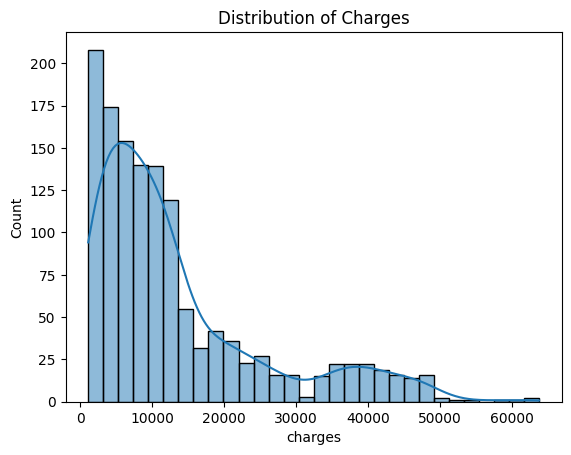

In [8]:
# Univariate Analysis(visualizations)
sns.histplot(df['charges'], kde=True)     # Distribution of insurance charges
plt.title('Distribution of Charges')
plt.show()

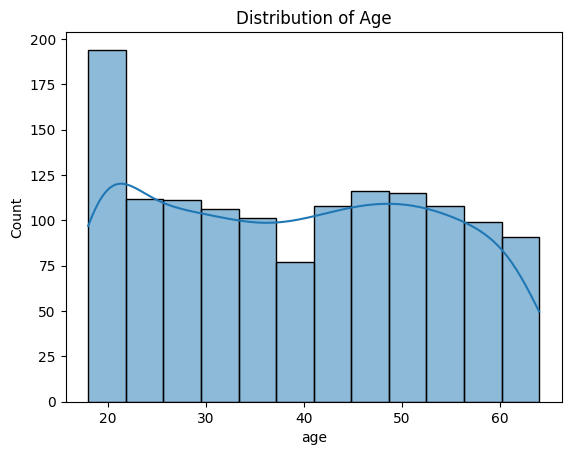

In [9]:
sns.histplot(df['age'], kde=True) # Distribution of insurance charges
plt.title('Distribution of Age')
plt.show()

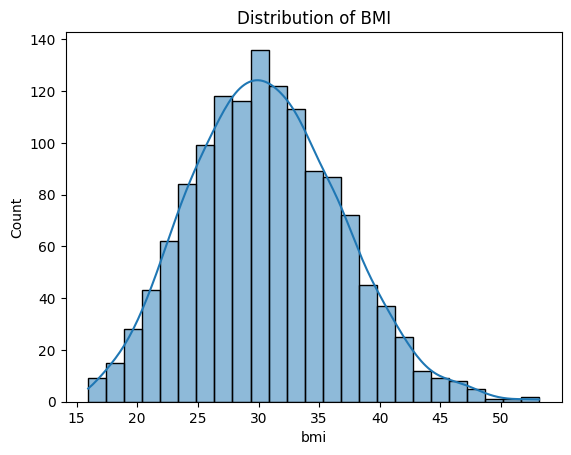

In [10]:
sns.histplot(df['bmi'], kde=True)         # Distribution of insurance charges
plt.title('Distribution of BMI')
plt.show()

In [11]:
#Encoding Categorical Variables bcs Linear Regression needs numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["sex"]    = le.fit_transform(df["sex"])           # male/female → 0/1
df["smoker"] = le.fit_transform(df["smoker"])        # yes/no → 1/0
df["region"] = le.fit_transform(df["region"])        # 4 regions → 0-3

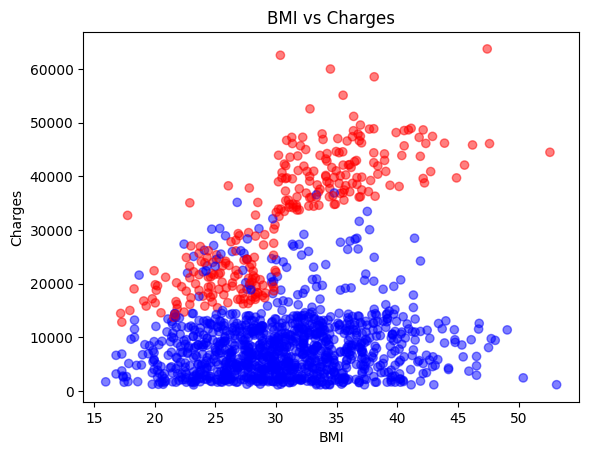

In [13]:
# BMI vs Charges
plt.scatter(df["bmi"], df["charges"], c=colors, alpha=0.5)
plt.xlabel("BMI"); plt.ylabel("Charges"); plt.title("BMI vs Charges")
plt.show()

Smokers (red) sit mostly between $20,000 – $60,000 in charges, regardless of BMI. Even a smoker with a healthy BMI pays far more than a non-smoker.
<br>
Non-smokers (blue) are densely packed at the bottom, mostly under $15,000, regardless of their BMI.
<br>
BMI still matters within smokers, as BMI increases among smokers, charges trend upward, showing a positive slope in the red cluster.

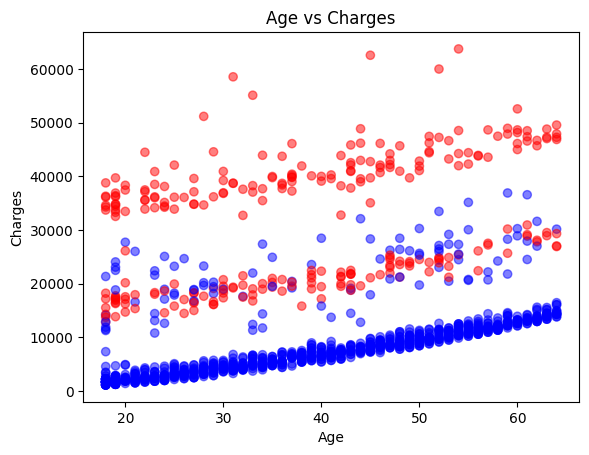

In [14]:
# Age vs Charges
plt.scatter(df["age"], df["charges"], c=colors, alpha=0.5)
plt.xlabel("Age"); plt.ylabel("Charges"); plt.title("Age vs Charges")
plt.show()

This chart reveals three patient tiers: non-smokers (cheapest), moderate smokers, and heavy smokers with high BMI (most expensive). Age increases charges gradually across all groups, but smoking creates a far bigger jump than aging ever does. A 20-year-old smoker pays more than a 60-year-old non-smoker.

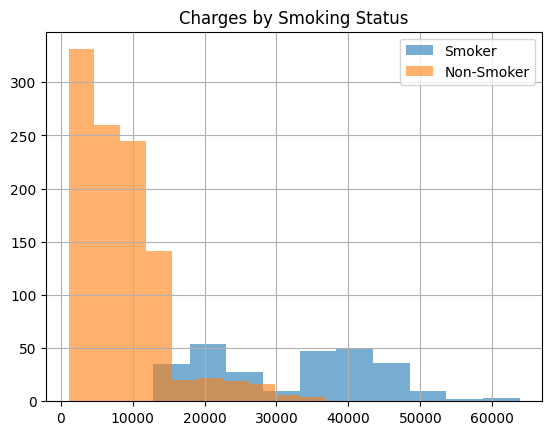

In [16]:
#Smoker vs Non-Smoker distribution
df_orig = pd.read_csv("insurance.csv")  # reload original
df_orig[df_orig["smoker"]=="yes"]["charges"].hist(label="Smoker", alpha=0.6)
df_orig[df_orig["smoker"]=="no"]["charges"].hist(label="Non-Smoker", alpha=0.6)
plt.legend(); plt.title("Charges by Smoking Status"); plt.show()

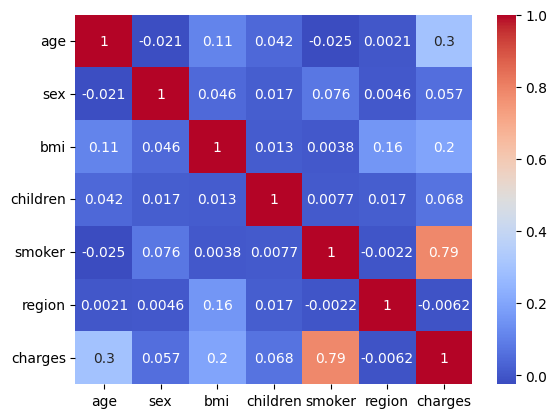

In [17]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

#### Split Features and Target

In [18]:
X = df.drop("charges", axis=1)
y = df["charges"]

#### Train/Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Train the Model

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_sc, y_train)

#### Evaluate with MAE and RMSE

In [23]:
y_pred = model.predict(X_test_sc)

print("MAE: ",  mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:  ",  r2_score(y_test, y_pred))

MAE:  4186.508898366437
RMSE: 5799.587091438359
R²:   0.7833463107364537


In conclusion, the model demonstrates good predictive performance, with an R² score of 0.783 indicating that it explains approximately 78.3% of the variance in the target variable. The MAE of 4186.51 shows that the model’s average prediction error is relatively moderate, while the RMSE of 5799.59 suggests that some larger errors are present. Overall, the results indicate that the model is reasonably accurate and effective, though there is still room for improvement in reducing prediction errors further.